Punctuation set: {'?', '~', '&', '#', '>', '$', '*', '=', '[', '\\', '^', '%', '"', '}', '_', ';', '`', ')', '<', '!', '.', '+', '{', ',', ':', '-', ']', "'", '(', '/', '@', '|'}
Additional punctuation set: {'".', '’.', '–,', '.”', '•', '—', ".'", '...', '’', "'m", '"', '–', "''", '",', "n't", "'s", '”.', '.', '’,', '“', '``', '‘', '”', "'", '—,', '”,', ').', '(‘', "'ve"}
Initial token count: 38307
token count 2: 34319
token count 3: 32104
token count 4: 17811
token count 5: 17811
token count after scrubbing: 17811
['I', 'imagine', 'the', 'British', 'press', 'gave', 'this', 'album', 'a', 'rough', 'time', 'considering', 'the', 'current', 'teenage', 'movement', 'there', 'and', 'let', "'", 's', 'face', 'it', ',', 'Procus', 'Harum', 'have', 'been', 'around', 'for', 'ten', 'years', 'or', 'more', '.', 'However', ',', 'this', 'is', 'N', '$', 'Z', '$', 'and', 'anything', 'with', 'more', 'gusto', 'than', 'a', 'metronome', 'tapping', 'is', 'worth', 'mentioning', 'in', 'the', 'hopes', 'that', 'th

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\OEM\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


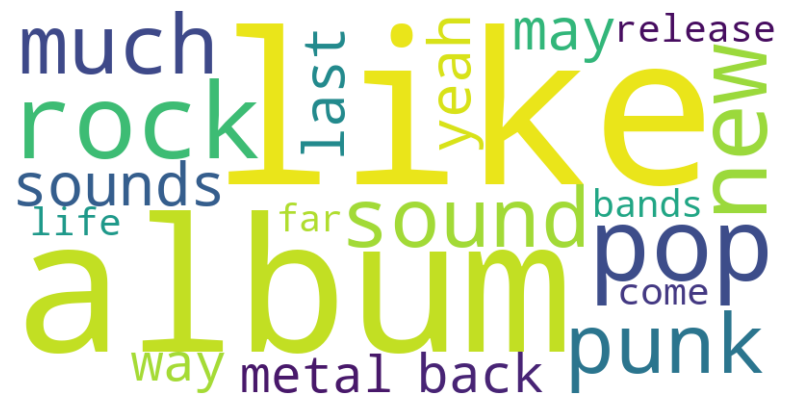

--- [('record', 46), ('group', 34), ('rhythm', 22), ('disco', 20), ('lyrics', 19), ('records', 18), ('however', 17), ('side', 15), ('music', 15), ('lofgren', 15), ('never', 14), ('love', 14), ('good', 14), ('studio', 14), ('arrangements', 14), ('playing', 13), ('less', 13), ('george', 13), ('strong', 12), ('dolly', 12)]


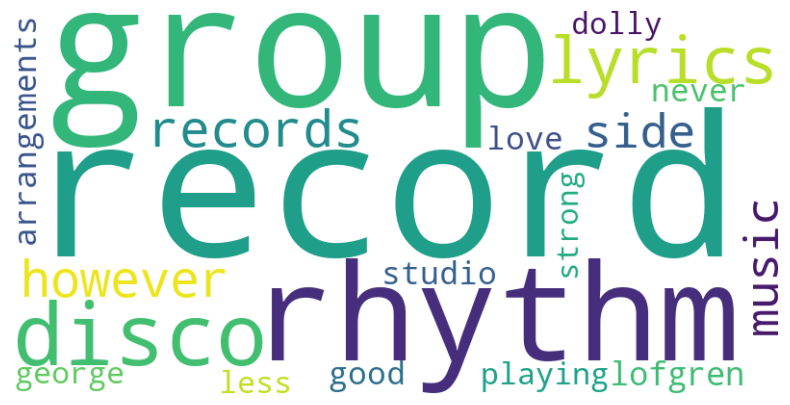

<class 'nltk.probability.FreqDist'>


In [16]:
from ast import pattern
import nltk
import string
from nltk.corpus import PlaintextCorpusReader
from nltk import FreqDist
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

punctuation_set = set(string.punctuation)
print("Punctuation set:", punctuation_set)
additional_punctuation = set(["'s", "'m", "'", '.', '"', "n't","'ve",'’', '“', '”', '–', '—', '...', '``', "''", '‘', '•', '”.', '",', '”,', '.”', ".'", '’,', '–,', '—,', '’.', '(‘', '".', ').'])
print("Additional punctuation set:", additional_punctuation)
reserved_words = set(["reviewed", "album", "record", "company","artist"])
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def do_scrubbing(tokens: list, remove_punctuation=True, remove_additional_puctuation=True, remove_stopwords=True, remove_reserved_words=True, lowercase=True):
    # Example scrubbing function (can be customized)
    print("Initial token count:", len(tokens))
    if lowercase:
        tokens = [token.lower() for token in tokens]
    if (remove_punctuation):
        tokens = [word for word in tokens if word not in punctuation_set]
        # tokens = [token.translate(str.maketrans('', '', string.punctuation)) for token in tokens]
    print("token count 2:", len(tokens))

    if remove_additional_puctuation:
        tokens = [word for word in tokens if word not in additional_punctuation]
    print("token count 3:", len(tokens))

    if remove_stopwords:
        tokens = [word for word in tokens if word not in stop_words]
    print("token count 4:", len(tokens))

    if remove_reserved_words:
        tokens = [word for word in tokens if word not in reserved_words]
    print("token count 5:", len(tokens))

    return tokens

def remove_header_lines(body: str, pattern: str) -> str:
    lines = body.split('\n')
    reg_exp = re.compile(pattern)
    cleaned_lines = [line for line in lines if not reg_exp.search(line)]
    return '\n'.join(cleaned_lines)

# Or use NLTK's PlaintextCorpusReader for a directory of text files
corpus_root = '.'  # Directory containing your text files
file_pattern = r'.*\.txt'  # Pattern to match .txt files
corpus = PlaintextCorpusReader(corpus_root, file_pattern)

# Access the text
# words = corpus.words('ALBUMS 97.06.01.txt')
raw_text_97 = corpus.raw(['ALBUMS 97.06.01.txt', 'ALBUMS 97.07.01.txt', 'ALBUMS 97.08.01.txt', 'ALBUMS 97.09.01.txt', 'ALBUMS 97.10.01.txt'])
raw_text_97 = remove_header_lines(raw_text_97, r'^(Reviewed By:|Artist:|Album:|Record Label:).*$')
raw_text_77 = corpus.raw(['RECORDS 77.06.01.txt', 'RECORDS 77.07.01.txt', 'RECORDS 77.08.01.txt', 'RECORDS 77.09.01.txt', 'RECORDS 77.10.01.txt'])
raw_text_77 = remove_header_lines(raw_text_77, r'^(Reviewed By:|Artist:|Album:|Record Label:).*$')

tokeniser = nltk.tokenize.WordPunctTokenizer()
# tokens_97 = nltk.word_tokenize(raw_text_97, language='english', preserve_line=True)
tokens_97 = tokeniser.tokenize(raw_text_97)
tokens_97 = do_scrubbing(tokens_97, remove_reserved_words=False)
print("token count after scrubbing:", len(tokens_97))
concordance_1 = FreqDist(tokens_97)
# tokens_77 = nltk.word_tokenize(raw_text_77, language='english', preserve_line=True)
tokens_77 = tokeniser.tokenize(raw_text_77)
print(tokens_77)
tokens_77 = do_scrubbing(tokens_77, remove_reserved_words=False)
print("token count after scrubbing:", len(tokens_77))
print(tokens_77)
concordance_2 = FreqDist(tokens_77)


print("***", concordance_1.most_common(100))
print("***", concordance_2.most_common(100))

more_in_1 = concordance_1 - concordance_2  # Words more common in first corpus
more_in_2 = concordance_2 - concordance_1  # Words more common in second corpus
print("---", more_in_1.most_common(20))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(more_in_1.most_common(20)))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Turn off the axis labels
plt.show()
print("---", more_in_2.most_common(20))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(dict(more_in_2.most_common(20)))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") # Turn off the axis labels
plt.show()
print(type(concordance_1))

Observations:
Notable 1977 words: record, group, disco, studio, love, side, one, rhythm
Notable 1997 words: album, rock, pop, country, like, sound, punk, may

To do:

Calculate average review lengths in words, by dividing the word count by the number of times "Reviewed By:" appears.

Paragraph lengths - word count divided by newlines?

See what NLTK can do in the way of estimating language complexity.

Some kind of estimation of punctuation use. E.g. comma count.

Created using the Rip It Up magazine archive at Papers Past. https://paperspast.natlib.govt.nz/periodicals/rip-it-up 

This archive is licensed for non-commercial use under a Creative Commons Attribution Non-Commercial Share Alike 3.0 (CC BY-NC-SA 3.0) licence. Rip it Up is not available for commercial use without the consent of Propeller Lamont Ltd.